# CD_A noepoch: early stopping vs fixed iterations

在随机 ER 图上比较 `dag_coordinate_descent_l0` 的早停和非早停版本，
对比 SHD、score 和 runtime。

In [1]:
import os
import sys
import time
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'synthetic_dataset.py').exists() and (candidate / 'coordinate_descent').exists():
            return candidate
    raise RuntimeError('Cannot locate repo root from current working directory.')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from synthetic_dataset import SyntheticDataset
from MEC import is_in_markov_equiv_class
from coordinate_descent.coordinate0 import (
    dag_coordinate_descent_l0 as cd_A_noepoch,
    f as cd_A_objective,
)

print('REPO_ROOT =', REPO_ROOT)

c:\Users\super\DAG\experiments\notebooks\test
REPO_ROOT = C:\Users\super\DAG


In [2]:
CFG = {
    'n_trials': 10,
    'dataset_seeds': list(range(1, 4)),  # 3 random ER graphs
    'algo_master_seed': 20260407,
    'n_samples': 10000,
    'd': 30,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 1.0,
    'threshold': 0.05,
    'lambda_l0': 0.2,
    # fixed-iteration budget
    'T': 100000,
    # early stopping params
    'tol': 1e-4,
    'patience': 10,
    'save_results': True,
}
CFG

{'n_trials': 10,
 'dataset_seeds': [1, 2, 3],
 'algo_master_seed': 20260407,
 'n_samples': 10000,
 'd': 30,
 'degree': 2.0,
 'noise_type': 'gaussian_nv',
 'b_scale': 1.0,
 'threshold': 0.05,
 'lambda_l0': 0.2,
 'T': 100000,
 'tol': 0.0001,
 'patience': 10,
 'save_results': True}

In [3]:
def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> int:
    return int(np.sum(np.abs(np.asarray(G_true, int) - np.asarray(G_est, int))))


def run_one_trial(S, G_true, seed, T, threshold, lambda_l0, early_stop, tol, patience):
    """Run cd_A noepoch once and return metrics dict."""
    t0 = time.perf_counter()
    A_est, G_est, score_end, history = cd_A_noepoch(
        S, T=T, seed=int(seed), threshold=threshold, lambda_l0=lambda_l0,
        return_history=True,
        early_stop=early_stop, tol=tol, patience=patience,
    )
    runtime = time.perf_counter() - t0
    return {
        'score': float(score_end),
        'shd': shd_score(G_true, G_est),
        'n_edges_est': int(G_est.sum()),
        'n_steps': len(history),
        'runtime_sec': runtime,
        'mec_match': int(is_in_markov_equiv_class(G_true, G_est)),
    }

In [4]:
rng = np.random.default_rng(CFG['algo_master_seed'])
algo_seeds = rng.integers(0, 10**9, size=CFG['n_trials'])

rows = []
for ds_seed in CFG['dataset_seeds']:
    dataset = SyntheticDataset(
        n=CFG['n_samples'], d=CFG['d'], graph_type='ER', degree=CFG['degree'],
        noise_type=CFG['noise_type'], B_scale=CFG['b_scale'], seed=ds_seed,
    )
    S = dataset.X.T @ dataset.X / dataset.X.shape[0]
    B_true = np.asarray(dataset.B, dtype=float)
    G_true = weight_to_binary_adj(B_true, threshold=0.0)
    n_edges_true = int(G_true.sum())
    print(f'\n=== dataset seed={ds_seed}, d={CFG["d"]}, true_edges={n_edges_true} ===')

    for trial_id, aseed in enumerate(algo_seeds, 1):
        for mode, es_flag in [('fixed', False), ('early_stop', True)]:
            m = run_one_trial(
                S, G_true, aseed, CFG['T'], CFG['threshold'], CFG['lambda_l0'],
                early_stop=es_flag, tol=CFG['tol'], patience=CFG['patience'],
            )
            rows.append({
                'dataset_seed': ds_seed,
                'trial_id': trial_id,
                'algo_seed': int(aseed),
                'mode': mode,
                'n_edges_true': n_edges_true,
                **m,
            })

        if trial_id <= 2 or trial_id % 10 == 0:
            r_fix = rows[-2]
            r_es  = rows[-1]
            print(
                f"  trial {trial_id:3d}  "
                f"fixed: shd={r_fix['shd']:2d} score={r_fix['score']:.4f} steps={r_fix['n_steps']:6d} rt={r_fix['runtime_sec']:.1f}s | "
                f"es:    shd={r_es['shd']:2d} score={r_es['score']:.4f} steps={r_es['n_steps']:6d} rt={r_es['runtime_sec']:.1f}s"
            )

df = pd.DataFrame(rows)
print(f'\nTotal rows: {len(df)}')
display(df.head(6))


=== dataset seed=1, d=30, true_edges=38 ===
  trial   1  fixed: shd=49 score=55.6748 steps=100000 rt=42.5s | es:    shd=49 score=55.6865 steps= 24645 rt=11.5s
  trial   2  fixed: shd=32 score=52.9477 steps=100000 rt=48.7s | es:    shd=32 score=52.9624 steps= 27900 rt=13.2s
  trial  10  fixed: shd=37 score=56.1143 steps=100000 rt=39.5s | es:    shd=37 score=56.1316 steps= 26970 rt=10.9s

=== dataset seed=2, d=30, true_edges=31 ===
  trial   1  fixed: shd=32 score=55.5147 steps=100000 rt=40.7s | es:    shd=32 score=55.5347 steps= 31155 rt=12.9s
  trial   2  fixed: shd=29 score=55.6107 steps=100000 rt=41.8s | es:    shd=29 score=55.6399 steps= 39525 rt=15.6s
  trial  10  fixed: shd=25 score=52.4445 steps=100000 rt=39.6s | es:    shd=25 score=52.4936 steps= 41850 rt=18.9s

=== dataset seed=3, d=30, true_edges=30 ===
  trial   1  fixed: shd=36 score=55.3280 steps=100000 rt=47.7s | es:    shd=36 score=55.4049 steps= 21855 rt=10.3s
  trial   2  fixed: shd=29 score=53.4336 steps=100000 rt=47.

,dataset_seed,trial_id,algo_seed,mode,n_edges_true,score,shd,n_edges_est,n_steps,runtime_sec,mec_match
0,1,1,18044244,fixed,38,55.674833,49,55,100000,42.515774,0
1,1,1,18044244,early_stop,38,55.686539,49,55,24645,11.462215,0
2,1,2,604916791,fixed,38,52.947730,32,46,100000,48.675010,0
3,1,2,604916791,early_stop,38,52.962372,32,46,27900,13.246172,0
4,1,3,837616598,fixed,38,57.036802,51,49,100000,44.685512,0
5,1,3,837616598,early_stop,38,57.040101,51,49,23250,10.251021,0


In [5]:
summary = (
    df.groupby('mode', as_index=False)
    .agg(
        trials=('shd', 'size'),
        shd_mean=('shd', 'mean'),
        shd_std=('shd', 'std'),
        shd_median=('shd', 'median'),
        score_mean=('score', 'mean'),
        score_std=('score', 'std'),
        n_steps_mean=('n_steps', 'mean'),
        n_steps_std=('n_steps', 'std'),
        runtime_mean=('runtime_sec', 'mean'),
        runtime_std=('runtime_sec', 'std'),
        mec_rate=('mec_match', 'mean'),
    )
)
print('Overall summary:')
display(summary)

Overall summary:


,mode,trials,shd_mean,shd_std,shd_median,score_mean,score_std,n_steps_mean,n_steps_std,runtime_mean,runtime_std,mec_rate
0,early_stop,30,31.400000,9.279566,29.5,54.429537,1.273061,27342.0,5423.335213,11.643182,2.516268,0.0
1,fixed,30,31.166667,9.519792,29.5,54.371977,1.307570,100000.0,0.000000,41.752703,4.229211,0.0


In [6]:
# Paired comparison: same (dataset_seed, algo_seed), early_stop vs fixed
df_fix = df[df['mode'] == 'fixed'].set_index(['dataset_seed', 'algo_seed'])
df_es  = df[df['mode'] == 'early_stop'].set_index(['dataset_seed', 'algo_seed'])

paired = df_fix[['shd', 'score', 'n_steps', 'runtime_sec']].join(
    df_es[['shd', 'score', 'n_steps', 'runtime_sec']], lsuffix='_fix', rsuffix='_es'
)
paired['shd_diff'] = paired['shd_es'] - paired['shd_fix']  # negative = es better
paired['score_diff'] = paired['score_es'] - paired['score_fix']
paired['speedup'] = paired['runtime_sec_fix'] / paired['runtime_sec_es']

print('Paired comparison (early_stop - fixed):')
print(f"  SHD diff:   mean={paired['shd_diff'].mean():.2f}, median={paired['shd_diff'].median():.1f}")
print(f"  Score diff: mean={paired['score_diff'].mean():.4f}")
print(f"  Speedup:    mean={paired['speedup'].mean():.2f}x, median={paired['speedup'].median():.2f}x")
print(f"  Steps (es): mean={paired['n_steps_es'].mean():.0f} vs (fix): {paired['n_steps_fix'].mean():.0f}")

Paired comparison (early_stop - fixed):
  SHD diff:   mean=0.23, median=0.0
  Score diff: mean=0.0576
  Speedup:    mean=3.72x, median=3.67x
  Steps (es): mean=27342 vs (fix): 100000


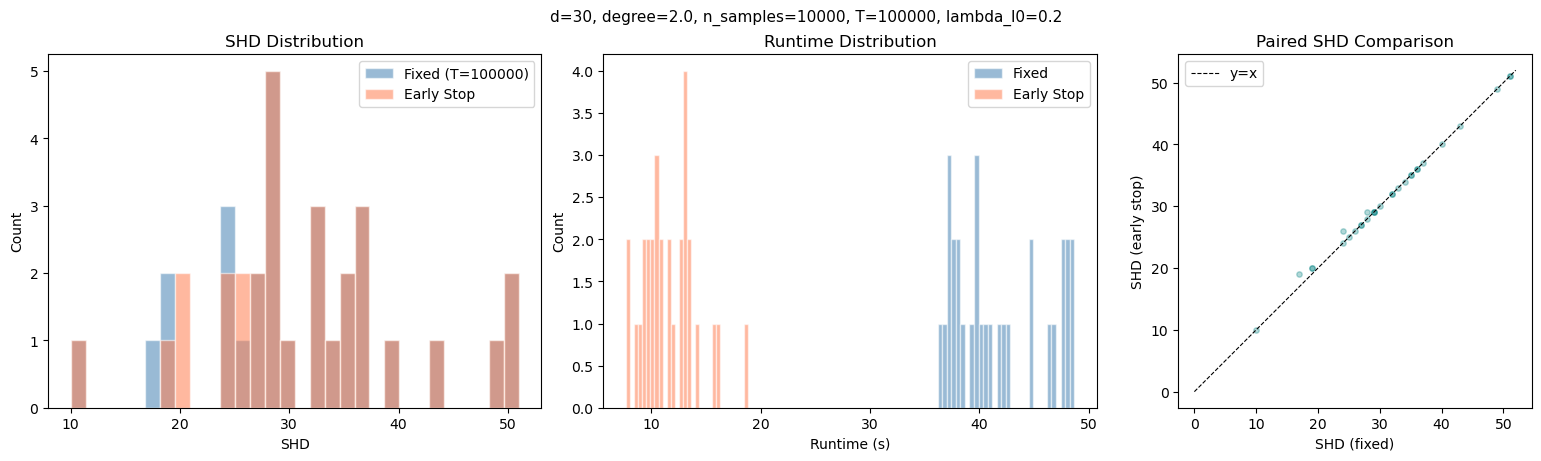

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# 1. SHD distribution
ax = axes[0]
for mode, color, label in [('fixed', 'steelblue', 'Fixed (T={})'.format(CFG['T'])),
                            ('early_stop', 'coral', 'Early Stop')]:
    sub = df[df['mode'] == mode]
    ax.hist(sub['shd'], bins=30, alpha=0.55, color=color, label=label, edgecolor='white')
ax.set_xlabel('SHD')
ax.set_ylabel('Count')
ax.set_title('SHD Distribution')
ax.legend()

# 2. Runtime distribution
ax = axes[1]
for mode, color, label in [('fixed', 'steelblue', 'Fixed'),
                            ('early_stop', 'coral', 'Early Stop')]:
    sub = df[df['mode'] == mode]
    ax.hist(sub['runtime_sec'], bins=30, alpha=0.55, color=color, label=label, edgecolor='white')
ax.set_xlabel('Runtime (s)')
ax.set_ylabel('Count')
ax.set_title('Runtime Distribution')
ax.legend()

# 3. Paired SHD scatter
ax = axes[2]
ax.scatter(paired['shd_fix'], paired['shd_es'], alpha=0.3, s=15, color='teal')
lim = max(paired['shd_fix'].max(), paired['shd_es'].max()) + 1
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='y=x')
ax.set_xlabel('SHD (fixed)')
ax.set_ylabel('SHD (early stop)')
ax.set_title('Paired SHD Comparison')
ax.legend()
ax.set_aspect('equal')

fig.suptitle(f'd={CFG["d"]}, degree={CFG["degree"]}, n_samples={CFG["n_samples"]}, T={CFG["T"]}, lambda_l0={CFG["lambda_l0"]}', fontsize=11)
plt.show()

In [8]:
# Per-dataset summary
per_ds = (
    df.groupby(['dataset_seed', 'mode'], as_index=False)
    .agg(
        shd_mean=('shd', 'mean'),
        score_mean=('score', 'mean'),
        runtime_mean=('runtime_sec', 'mean'),
        n_steps_mean=('n_steps', 'mean'),
    )
)
print('Per-dataset summary:')
display(per_ds.pivot(index='dataset_seed', columns='mode', values=['shd_mean', 'runtime_mean', 'n_steps_mean']))

Per-dataset summary:


shd_mean       runtime_mean            n_steps_mean          
mode         early_stop fixed   early_stop      fixed   early_stop     fixed
dataset_seed                                                                
1                  39.6  39.6    11.821011  44.123137      26086.5  100000.0
2                  26.4  25.7    12.873149  38.899367      32271.0  100000.0
3                  28.2  28.2    10.235386  42.235606      23668.5  100000.0

In [9]:
if CFG['save_results']:
    out_dir = REPO_ROOT / 'experiments' / 'results'
    out_dir.mkdir(parents=True, exist_ok=True)

    trials_csv = out_dir / 'cd_A_early_stop_trials.csv'
    summary_csv = out_dir / 'cd_A_early_stop_summary.csv'
    df.to_csv(trials_csv, index=False)
    summary.to_csv(summary_csv, index=False)
    print(f'Saved:\n - {trials_csv}\n - {summary_csv}')

Saved:
 - C:\Users\super\DAG\experiments\results\cd_A_early_stop_trials.csv
 - C:\Users\super\DAG\experiments\results\cd_A_early_stop_summary.csv
